# Revisiting the T-Cell Model in Python

A code walkthrough of `src/rules_data.py`, `src/logic_engine.py`, and `src/run_analysis.py` — the three files behind the [case study](https://github.com/ncdomingues/tcell-mirna-model).

**What this is.** In 2019 I built a logical (Boolean / multi-valued) network model in GINsim + R for my PhD thesis, predicting what the microRNA miR-34c-5p does inside an activated human CD4⁺ T cell. This notebook rebuilds a piece of that model from scratch in plain Python — no GINsim, no R, no external logical-modelling package — and runs it live, cell by cell, so every step is inspectable.

**Source of truth.** The 76-node, 89-formula rule table in `rules_data.py` is transcribed verbatim from Table 5 of the actual thesis (`Results_PhDthesis.docx`), including its base models: Saez-Rodriguez et al. 2007 (proximal TCR signalling), Naldi et al. 2010 and Abou-Jaoudé et al. 2015 (Th differentiation).

Run this notebook top to bottom — each section builds on the last, ending with the same four-condition comparison used in `run_analysis.py`.

## 1. The rule table (`rules_data.py`)

This module is pure data: a list of `(node, target_value, formula, description)` tuples, one per row of the thesis's Table 5. Nothing here is inferred or reconstructed from memory — it's a direct transcription.

A node can have more than one entry (e.g. `NFKB` has a value-2 rule and a value-1 rule) — that's *multi-valued threshold logic*: the node takes the **highest** value whose formula is satisfied.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rules_data import RULES, ALIASES, SOURCE
from logic_engine import tokenize, parse_formula, collect_refs, eval_ast, LogicalModel

print(f"{len(RULES)} rule rows loaded")
print(f"{len({r[0] for r in RULES})} distinct rule-governed nodes")
print()
print(SOURCE)

89 rule rows loaded
76 distinct rule-governed nodes

Table 5, Results_PhDthesis.docx -- Nuno Domingues PhD thesis, 'sncRNA regulatory networks in T cell activation and viral response', Universidade de Lisboa, 2019. Base models: Saez-Rodriguez et al. 2007 (PLoS Comput Biol 3(8):e163); Naldi et al. 2010 (PLoS Comput Biol 6(9):e1000912); Abou-Jaoude et al. 2015 (Front Bioeng Biotechnol 2:86).


In [2]:
# The two miRNA nodes, exactly as they appear in the thesis table
for node, value, formula, desc in RULES:
    if node in ("miR-34c-5p", "miR-155-5p"):
        print(f"{node} = {value}  if  {formula}")
        print(f"   -- {desc}\n")

miR-34c-5p = 2  if  GATA3 & MYC & (TP53 | FOXO3 | SP1)
   -- Enhanced miR-34c-5p transcription: GATA3+MYC plus one of TP53/FOXO3/SP1 (ChIP-seq-supported).

miR-34c-5p = 1  if  GATA3 & MYC
   -- Baseline miR-34c-5p transcription requires GATA3 and MYC (which themselves control T-cell proliferation).

miR-155-5p = 1  if  NFKB & NFAT & (TBX21 | GATA3 | RORC | FOXP3)
   -- Enhanced miR-155-5p transcription with a Th master regulator present.

miR-155-5p = 1  if  NFKB & NFAT
   -- Baseline miR-155-5p transcription shortly after activation, requiring NFAT and NFKB.



## 2. Parsing the thesis's own notation (`logic_engine.py`)

The formulas use `&` (AND), `|` (OR), `!` (NOT), and `NODE:k` ("NODE has reached level k or higher"). Node names themselves contain hyphens (`AKT1-PKB`, `miR-34c-5p`), which rules out naive regex substitution — so `logic_engine.py` has a small hand-written **tokenizer** and **recursive-descent parser** instead.

Precedence follows Python's own `not` > `and` > `or` binding — the natural reading of `A & B | C & !D` as `(A&B) | (C & !D)`.

In [3]:
# Tokenizing a real formula from the table -- IL2's value-2 rule
formula = "(NFAT & NFKB) | (JUN & FOS) & STAT5 & !(STAT5 & STAT6) & !(NFKB & TBX21)"
tokens = tokenize(formula)
print("Formula:", formula)
print("\nTokens:")
for kind, text in tokens:
    print(f"  {kind:8s} {text}")

Formula: (NFAT & NFKB) | (JUN & FOS) & STAT5 & !(STAT5 & STAT6) & !(NFKB & TBX21)

Tokens:
  LPAREN   (
  IDENT    NFAT
  AND      &
  IDENT    NFKB
  RPAREN   )
  OR       |
  LPAREN   (
  IDENT    JUN
  AND      &
  IDENT    FOS
  RPAREN   )
  AND      &
  IDENT    STAT5
  AND      &
  NOT      !
  LPAREN   (
  IDENT    STAT5
  AND      &
  IDENT    STAT6
  RPAREN   )
  AND      &
  NOT      !
  LPAREN   (
  IDENT    NFKB
  AND      &
  IDENT    TBX21
  RPAREN   )


In [4]:
# Parsing it into an AST -- notice the precedence: the OR splits the formula into
# exactly two branches, "(NFAT & NFKB)" and everything after the first "|"
ast = parse_formula(formula)
ast

('OR',
 ('AND', ('REF', 'NFAT', None), ('REF', 'NFKB', None)),
 ('AND',
  ('AND',
   ('AND',
    ('AND', ('REF', 'JUN', None), ('REF', 'FOS', None)),
    ('REF', 'STAT5', None)),
   ('NOT', ('AND', ('REF', 'STAT5', None), ('REF', 'STAT6', None)))),
  ('NOT', ('AND', ('REF', 'NFKB', None), ('REF', 'TBX21', None)))))

## 3. Evaluating a formula against a state

`eval_ast` walks the AST against a dict of `{node_name: value}`. A bare reference like `NFAT` means "NFAT's value is >= 1"; a threshold reference like `IL2R:2` means "IL2R's value is >= 2". Let's check the IL2 value-2 formula above against two toy states.

In [5]:
state_a = {"NFAT": 1, "NFKB": 1, "JUN": 0, "FOS": 0, "STAT5": 0, "STAT6": 0, "TBX21": 0}
state_b = {"NFAT": 0, "NFKB": 0, "JUN": 1, "FOS": 1, "STAT5": 1, "STAT6": 1, "TBX21": 0}

print("State A (classic NFAT+NFKB route):", eval_ast(ast, state_a, ALIASES))
print("State B (AP1/STAT5 route, but blocked by STAT5+STAT6):", eval_ast(ast, state_b, ALIASES))

State A (classic NFAT+NFKB route): True
State B (AP1/STAT5 route, but blocked by STAT5+STAT6): False


## 4. Assembling the whole network (`LogicalModel`)

`LogicalModel.__init__` parses every rule once, then works out which node names are **rule-governed** (appear as a target) versus **inputs** (referenced somewhere but never assigned a rule -- these are held constant for a whole simulation, representing sustained antigen/co-receptor presence in vitro).

In [6]:
model = LogicalModel(RULES, ALIASES)

print(f"Rule-governed nodes: {len(model.rule_nodes)}")
print(f"Input nodes (held constant): {model.input_nodes}")
print(f"Total nodes in the network: {len(model.all_nodes)}")

Rule-governed nodes: 76
Input nodes (held constant): ['APC-Antigen', 'CD3', 'CD45RA', 'CGC', 'CREBBP']
Total nodes in the network: 81


In [7]:
# evaluate_node() checks a node's rules in decreasing order of target value
# and returns the first one that's satisfied -- this is the threshold semantics in action
test_state = {"GATA3": 1, "MYC": 1, "TP53": 1, "FOXO3": 0, "SP1": 0}
print("miR-34c-5p level given GATA3+MYC+TP53:", model.evaluate_node("miR-34c-5p", test_state))

test_state2 = {"GATA3": 1, "MYC": 1, "TP53": 0, "FOXO3": 0, "SP1": 0}
print("miR-34c-5p level given only GATA3+MYC:  ", model.evaluate_node("miR-34c-5p", test_state2))

miR-34c-5p level given GATA3+MYC+TP53: 2
miR-34c-5p level given only GATA3+MYC:   1


## 5. One asynchronous trajectory

`async_run` starts from an initial state and updates **one randomly-chosen node at a time** (the update order is reshuffled every full sweep through all rule-governed nodes) -- this is the standard "asynchronous update" scheme for logical models, and avoids the artificial lock-step artifacts a synchronous (update-everything-at-once) scheme can introduce.

We start from an unstimulated cell and switch on the receptor/co-receptor inputs that represent TCR + IL2 stimulation.

In [8]:
import random

initial_state = {n: 0 for n in model.all_nodes}
for inp in ("APC-Antigen", "CD3", "CD45RA", "CGC", "CREBBP"):
    initial_state[inp] = 1

rng = random.Random(7)
final_state, history = model.async_run(initial_state, n_steps=10 * len(model.rule_nodes), rng=rng)

watch = ["TCR", "NFAT", "NFKB", "GATA3", "TBX21", "RORC", "FOXP3", "miR-34c-5p", "miR-155-5p"]
print(f"{'node':12s} {'initial':>8s} {'final':>8s}")
for n in watch:
    print(f"{n:12s} {initial_state.get(n,0):8d} {final_state.get(n,0):8d}")

node          initial    final
TCR                 0        1
NFAT                0        0
NFKB                0        0
GATA3               0        0
TBX21               0        0
RORC                0        1
FOXP3               0        1
miR-34c-5p          0        0
miR-155-5p          0        0


## 6. From one run to an ensemble

A single trajectory depends on the random update order -- it's noisy. `ensemble_run` repeats the process many times from the *same* initial condition and averages, at each sweep, what fraction of runs have each node active. That average trajectory is the modern equivalent of the thesis's own Figure 11/12 ("node behaviour/evolution, average active fraction").

Here's a quick 100-run ensemble (the full analysis in `run_analysis.py` uses 400) for GATA3 and RORC.

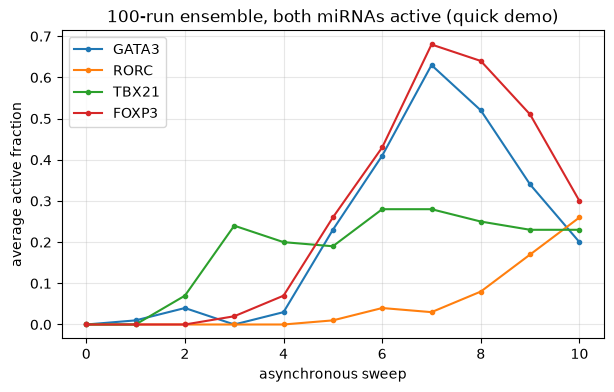

In [9]:
finals, traj = model.ensemble_run(initial_state, n_sweeps=10, n_runs=100, seed=1)

fig, ax = plt.subplots(figsize=(7, 4))
for node in ["GATA3", "RORC", "TBX21", "FOXP3"]:
    ax.plot(traj[node], marker="o", markersize=3, label=node)
ax.set_xlabel("asynchronous sweep")
ax.set_ylabel("average active fraction")
ax.set_title("100-run ensemble, both miRNAs active (quick demo)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 7. The four-condition comparison (`run_analysis.py`)

This is the actual experiment: build **four versions** of the network by including or excluding the two miRNAs' own transcriptional rules, then compare.

| Condition | miR-34c-5p rule included? | miR-155-5p rule included? |
|---|---|---|
| `no miRNA` | no (fixed at 0) | no (fixed at 0) |
| `miR-34c-5p only` | yes | no (fixed at 0) |
| `miR-155-5p only` | no (fixed at 0) | yes |
| `both` | yes | yes |

Removing a node's rule automatically demotes it to an "input" in `LogicalModel` (see Section 4), which we then pin at 0 -- a clean way to simulate a knockout without touching the rest of the network.

In [10]:
from run_analysis import (
    build_condition_models, base_initial_state, run_all,
    activation_frequency_table, phenotype_table, WATCHLIST, MASTER_TFS,
    N_SWEEPS, N_RUNS, SEED,
)

# run_analysis.py sets a non-interactive backend for its own headless script use;
# restore inline rendering for the rest of this notebook
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")

print(f"Running {len(MASTER_TFS)+len(WATCHLIST)} watched nodes x 4 conditions x {N_RUNS} runs x {N_SWEEPS} sweeps...")
conditions, results = run_all()
print("Done.")

Running 27 watched nodes x 4 conditions x 400 runs x 10 sweeps...


Done.


### Results table 1 -- general node activation frequency

Percentage of the 400 final states in which each watched node was active (>= 1), by condition.

In [11]:
ss_table = activation_frequency_table(results, WATCHLIST)
ss_table

,no miRNA,miR-155-5p only,miR-34c-5p only,both
NFAT,21.0,28.8,24.8,25.8
NFKB,29.8,11.8,34.5,11.0
STAT3,49.0,39.5,40.8,30.2
STAT5,79.0,72.5,80.5,68.8
TBX21,27.0,36.2,30.0,38.2
GATA3,44.0,15.5,45.2,13.8
RORC,34.8,24.8,29.8,20.8
FOXP3,23.8,31.5,22.8,30.2
BCL6,50.5,22.2,43.5,19.2
AHR,40.2,14.0,30.5,9.8


### Results table 2 -- Th-subtype master regulators

The transcription factors that actually define T-helper identity: TBX21 (Th1), GATA3 (Th2), RORC (Th17), FOXP3 (iTreg), BCL6 (Tfh), AHR (Th22), SPI1-PU1 (Th9).

In [12]:
pheno_df = phenotype_table(results)
pheno_df

,no miRNA,miR-155-5p only,miR-34c-5p only,both
Th1,27.0,36.2,30.0,38.2
Th2,44.0,15.5,45.2,13.8
Th17,34.8,24.8,29.8,20.8
iTreg,23.8,31.5,22.8,30.2
Tfh,50.5,22.2,43.5,19.2
Th22,40.2,14.0,30.5,9.8
Th9,37.8,4.5,33.2,3.0


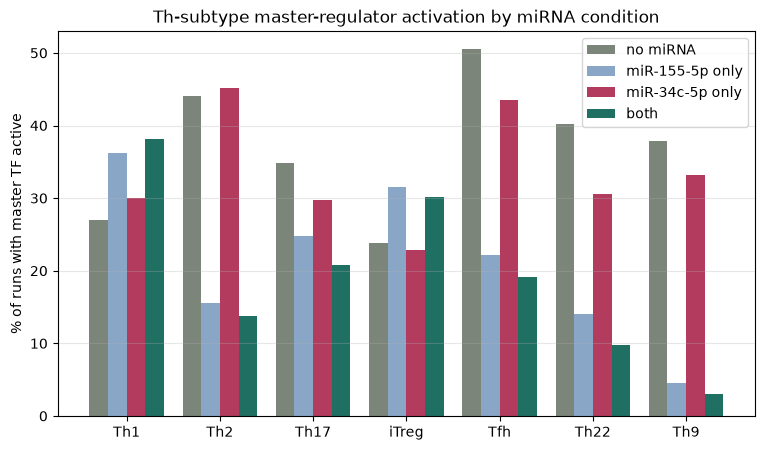

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(pheno_df.index))
width = 0.2
colors = ["#7C8579", "#8AA6C7", "#B23B5E", "#1F6F63"]
for i, cond in enumerate(pheno_df.columns):
    ax.bar(x + (i - 1.5) * width, pheno_df[cond], width, label=cond, color=colors[i])
ax.set_xticks(x)
ax.set_xticklabels(pheno_df.index)
ax.set_ylabel("% of runs with master TF active")
ax.set_title("Th-subtype master-regulator activation by miRNA condition")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.show()

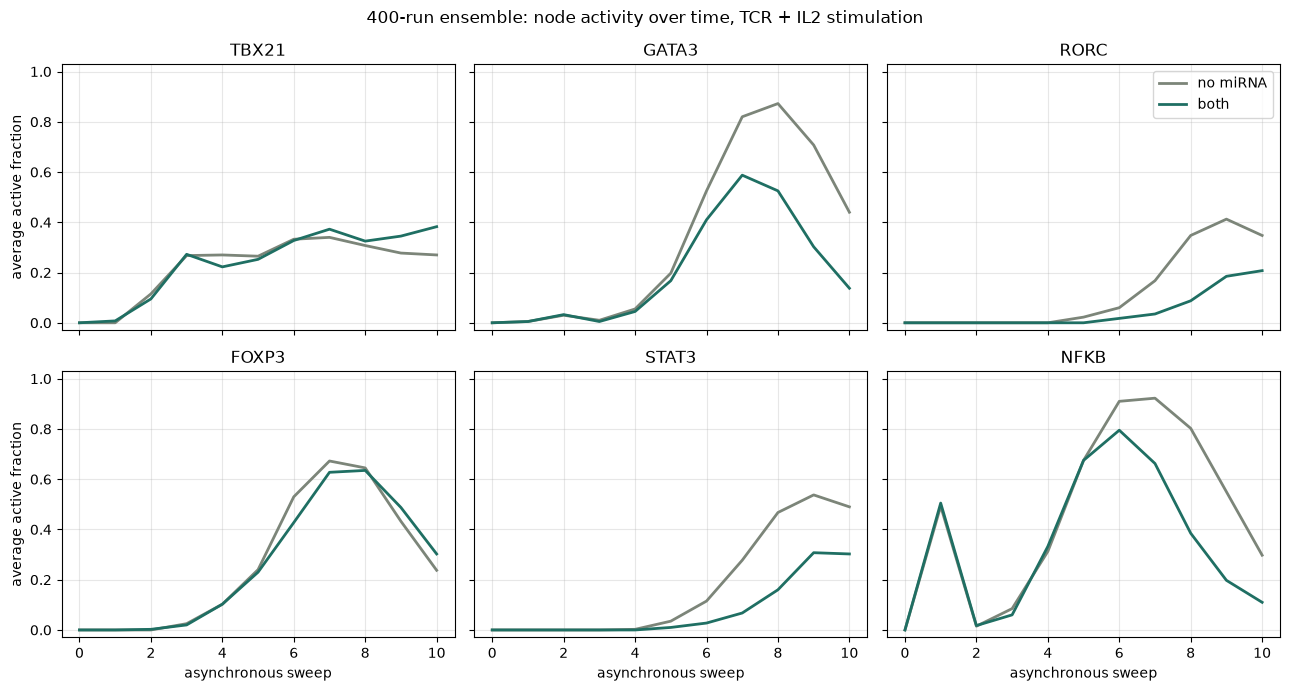

In [14]:
# Same node-activity-over-time view as Section 6, now for the full 400-run
# ensembles, no-miRNA baseline vs. both miRNAs active
tfs = ["TBX21", "GATA3", "RORC", "FOXP3", "STAT3", "NFKB"]
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
for ax, tf in zip(axes.flat, tfs):
    ax.plot(results["no miRNA"]["traj"][tf], label="no miRNA", color="#7C8579", linewidth=2)
    ax.plot(results["both"]["traj"][tf], label="both", color="#1F6F63", linewidth=2)
    ax.set_title(tf)
    ax.set_ylim(-0.03, 1.03)
    ax.grid(alpha=0.3)
axes[0, 0].set_ylabel("average active fraction")
axes[1, 0].set_ylabel("average active fraction")
for ax in axes[1]:
    ax.set_xlabel("asynchronous sweep")
axes[0, -1].legend()
fig.suptitle("400-run ensemble: node activity over time, TCR + IL2 stimulation")
fig.tight_layout()
plt.show()

## 8. Reading the results

**miR-155-5p is the dominant driver.** On its own it suppresses the Th2/Tfh/Th22/Th9-associated master regulators (GATA3, BCL6, AHR, SPI1-PU1) and nudges Th1/iTreg (TBX21, FOXP3) upward. **miR-34c-5p alone barely moves the needle** from the no-miRNA baseline -- but combined with miR-155-5p, it suppresses that same Th2/Tfh/Th22/Th9 branch *further* than miR-155-5p does by itself. That's a cooperative, not purely additive, effect.

**Where this agrees with the 2019 thesis:** both versions agree that the two miRNAs measurably reshape the T-cell fate-decision network, and that their effects are not simply additive -- the central, defensible claim from 2019 survives an independent reimplementation.

**Where it diverges:** the original discussion leaned toward a Th17/iTreg-specific shift; this rebuild instead centres the effect on miR-155-5p with miR-34c-5p as an amplifier. The most likely causes -- a genuinely different simulation methodology (asynchronous Monte Carlo averaging here vs. GINsim/MaBoSS steady-state enumeration in 2019), and two formulas (`SIRT1`, `MAF`) whose operator grouping is ambiguous exactly as published -- are documented in full in [`MODEL_NOTES.md`](https://github.com/ncdomingues/tcell-mirna-model/blob/main/MODEL_NOTES.md) rather than tuned away.

---

**Links:** [full repository](https://github.com/ncdomingues/tcell-mirna-model) · [MODEL_NOTES.md](https://github.com/ncdomingues/tcell-mirna-model/blob/main/MODEL_NOTES.md) · [narrated case study](../NunoDomingues-Website/case-study-tcell-model.html)